#   Plotly Dashboard
### Sales Data Analysis and Forecasting 
---

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# ── Load cleaned dataset ──────────────────────────────────
df = pd.read_csv('cleaned_sales_data.csv', parse_dates=['Order_Date','Ship_Date'])

# ── Plotly dark theme defaults ────────────────────────────
DARK_LAYOUT = dict(
    paper_bgcolor='#0d1117',
    plot_bgcolor='#161b22',
    font=dict(color='#c9d1d9', family='monospace'),
    xaxis=dict(gridcolor='#21262d', linecolor='#30363d', zerolinecolor='#30363d'),
    yaxis=dict(gridcolor='#21262d', linecolor='#30363d', zerolinecolor='#30363d'),
    legend=dict(bgcolor='#161b22', bordercolor='#30363d', borderwidth=1),
    hoverlabel=dict(bgcolor='#1c2128', bordercolor='#58a6ff', font_color='#c9d1d9'),
    margin=dict(l=60, r=30, t=60, b=50),
)
COLORS = ['#58a6ff','#3fb950','#f78166','#d2a8ff','#ffa657','#79c0ff']
print(" Plotly loaded. Dark theme configured.")
print(f"   Dataset: {df.shape[0]} rows × {df.shape[1]} columns")

 Plotly loaded. Dark theme configured.
   Dataset: 1000 rows × 18 columns


---
##  Chart 1 — Monthly Sales Trend (Interactive)
Hover over lines · Click legend to toggle years · Drag to zoom

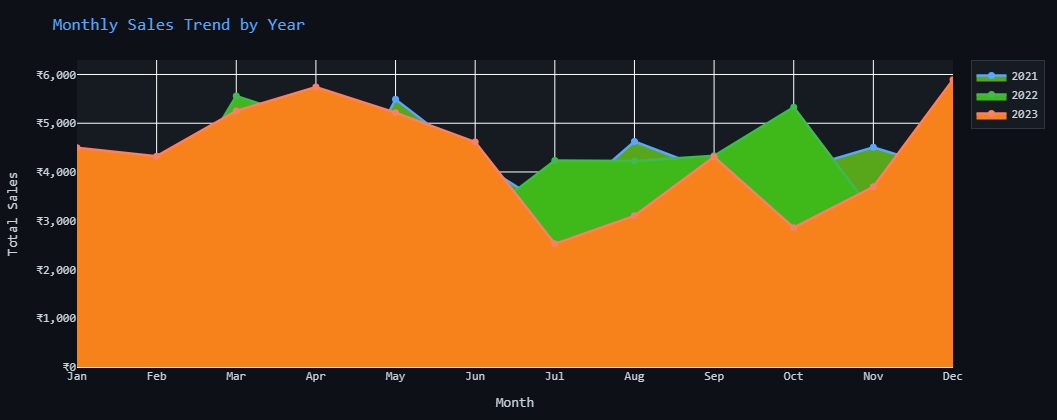

In [2]:
monthly = df.groupby(['Year','Month'])['Sales'].sum().reset_index()

fig = go.Figure()
for yr, color in zip(sorted(monthly['Year'].unique()), COLORS):
    sub = monthly[monthly['Year'] == yr]
    fig.add_trace(go.Scatter(
        x=sub['Month'], y=sub['Sales'],
        mode='lines+markers',
        name=str(yr),
        line=dict(color=color, width=2.5),
        marker=dict(size=7, symbol='circle'),
        fill='tozeroy', fillcolor=color.replace('ff','1a').replace('50','1a').replace('66','1a'),
        hovertemplate='<b>%{fullData.name}</b><br>Month %{x}<br>Sales: ₹%{y:,.0f}<extra></extra>'
    ))

fig.update_layout(
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font=dict(color='#c9d1d9', family='monospace'),
    legend=dict(bgcolor='#161b22', bordercolor='#30363d', borderwidth=1),
    hoverlabel=dict(bgcolor='#1c2128', bordercolor='#58a6ff', font_color='#c9d1d9'),
    margin=dict(l=60, r=30, t=60, b=50),
    title=dict(text=' Monthly Sales Trend by Year', font=dict(size=17, color='#58a6ff')),
    xaxis=dict(tickmode='array',
               tickvals=list(range(1,13)),
               ticktext=['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'],
               title='Month'),
    yaxis=dict(tickprefix='₹', tickformat=',.0f', title='Total Sales'),
    height=420
)
fig.show()

---
##  Chart 2 — Category & Region Breakdown
Hover for exact values · Click slices to explode

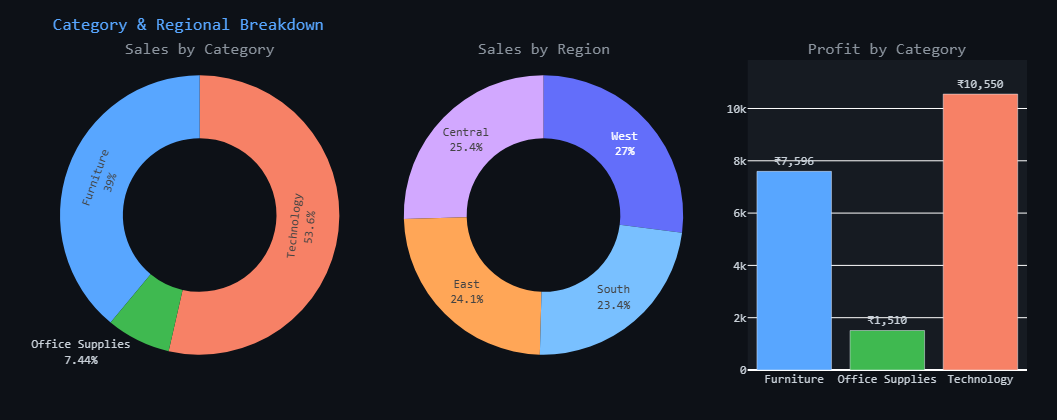

In [3]:
cat_sales   = df.groupby('Category')['Sales'].sum().reset_index()
reg_sales   = df.groupby('Region')['Sales'].sum().reset_index()
cat_profit  = df.groupby('Category')['Profit'].sum().reset_index()

fig = make_subplots(rows=1, cols=3,
                    specs=[[{'type':'domain'},{'type':'domain'},{'type':'xy'}]],
                    subplot_titles=['Sales by Category','Sales by Region','Profit by Category'])

# Donut 1 — Category Sales
fig.add_trace(go.Pie(
    labels=cat_sales['Category'], values=cat_sales['Sales'],
    hole=0.55, marker_colors=COLORS[:3],
    hovertemplate='<b>%{label}</b><br>₹%{value:,.0f}<br>%{percent}<extra></extra>',
    textinfo='label+percent'), row=1, col=1)

# Donut 2 — Region Sales
fig.add_trace(go.Pie(
    labels=reg_sales['Region'], values=reg_sales['Sales'],
    hole=0.55, marker_colors=COLORS[3:],
    hovertemplate='<b>%{label}</b><br>₹%{value:,.0f}<br>%{percent}<extra></extra>',
    textinfo='label+percent'), row=1, col=2)

# Bar — Profit
fig.add_trace(go.Bar(
    x=cat_profit['Category'], y=cat_profit['Profit'],
    marker_color=COLORS[:3],
    hovertemplate='<b>%{x}</b><br>Profit: ₹%{y:,.0f}<extra></extra>',
    text=[f'₹{v:,.0f}' for v in cat_profit['Profit']],
    textposition='outside', textfont_color='#c9d1d9'), row=1, col=3)

fig.update_layout(
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font=dict(color='#c9d1d9', family='monospace'),
    legend=dict(bgcolor='#161b22', bordercolor='#30363d', borderwidth=1),
    hoverlabel=dict(bgcolor='#1c2128', bordercolor='#58a6ff', font_color='#c9d1d9'),
    margin=dict(l=60, r=30, t=60, b=50),
    title=dict(text=' Category & Regional Breakdown', font=dict(size=17, color='#58a6ff')),
    showlegend=False, height=420,
    yaxis3=dict(gridcolor='#21262d', linecolor='#30363d',
                tickprefix='₹', tickformat=',.0f')
)
fig.update_annotations(font_color='#8b949e')
fig.show()

---
##  Chart 3 — Region × Category Heatmap (Interactive)

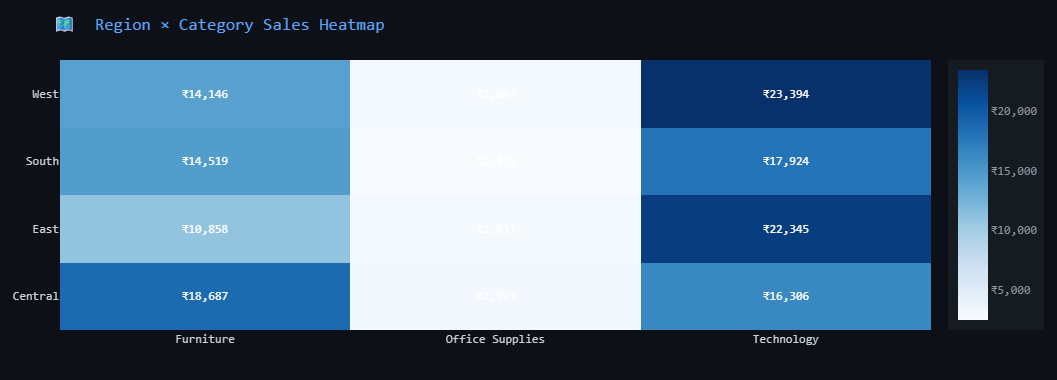

In [4]:
pivot = df.pivot_table(index='Region', columns='Category',
                       values='Sales', aggfunc='sum').round(0)

fig = go.Figure(go.Heatmap(
    z=pivot.values,
    x=pivot.columns.tolist(),
    y=pivot.index.tolist(),
    colorscale='Blues',
    text=[[f'₹{v:,.0f}' for v in row] for row in pivot.values],
    texttemplate='%{text}',
    textfont=dict(size=12, color='white'),
    hovertemplate='Region: <b>%{y}</b><br>Category: <b>%{x}</b><br>Sales: ₹%{z:,.0f}<extra></extra>',
    colorbar=dict(tickprefix='₹', tickformat=',.0f',
                  bgcolor='#161b22', bordercolor='#30363d',
                  outlinecolor='#30363d', tickcolor='#8b949e',
                  tickfont=dict(color='#8b949e'))
))

fig.update_layout(
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font=dict(color='#c9d1d9', family='monospace'),
    legend=dict(bgcolor='#161b22', bordercolor='#30363d', borderwidth=1),
    hoverlabel=dict(bgcolor='#1c2128', bordercolor='#58a6ff', font_color='#c9d1d9'),
    margin=dict(l=60, r=30, t=60, b=50),
    title=dict(text='🗺️  Region × Category Sales Heatmap', font=dict(size=17, color='#58a6ff')),
    height=380
)
fig.show()

---
##  Chart 4 — Discount vs Profit (Bubble Chart)
Bubble size = Order quantity · Hover for full details

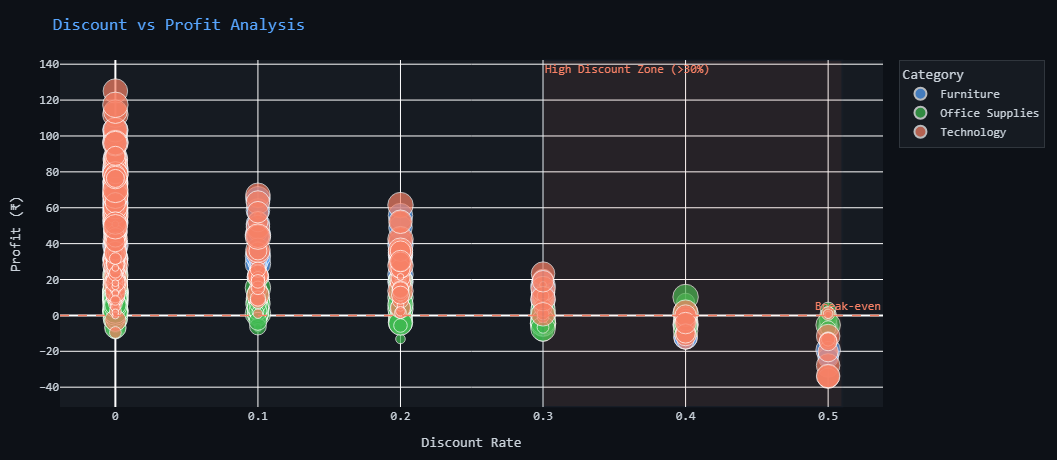

In [5]:
df['Quantity'] = df['Quantity'].fillna(1).astype(float)
fig = px.scatter(
    df, x='Discount', y='Profit', color='Category',
    size='Quantity', size_max=18,
    color_discrete_sequence=COLORS,
    hover_data={'Order_ID': True, 'Sales': ':,.0f',
                'Quantity': True, 'Region': True},
    labels={'Discount': 'Discount Rate', 'Profit': 'Profit (₹)'}
)

fig.add_hline(y=0, line_dash='dash', line_color='#f78166',
              line_width=1.5, annotation_text='Break-even',
              annotation_font_color='#f78166')
fig.add_vrect(x0=0.3, x1=df['Discount'].max()+0.01,
              fillcolor='#f78166', opacity=0.07,
              annotation_text='High Discount Zone (>30%)',
              annotation_font_color='#f78166',
              annotation_position='top left')

fig.update_layout(
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font=dict(color='#c9d1d9', family='monospace'),
    legend=dict(bgcolor='#161b22', bordercolor='#30363d', borderwidth=1),
    hoverlabel=dict(bgcolor='#1c2128', bordercolor='#58a6ff', font_color='#c9d1d9'),
    margin=dict(l=60, r=30, t=60, b=50),
    title=dict(text=' Discount vs Profit Analysis', font=dict(size=17, color='#58a6ff')),
    height=460
)
fig.show()

---
##  Chart 5 — Quarterly Sales by Region (Grouped Bar)
Click legend to isolate regions · Double-click to reset

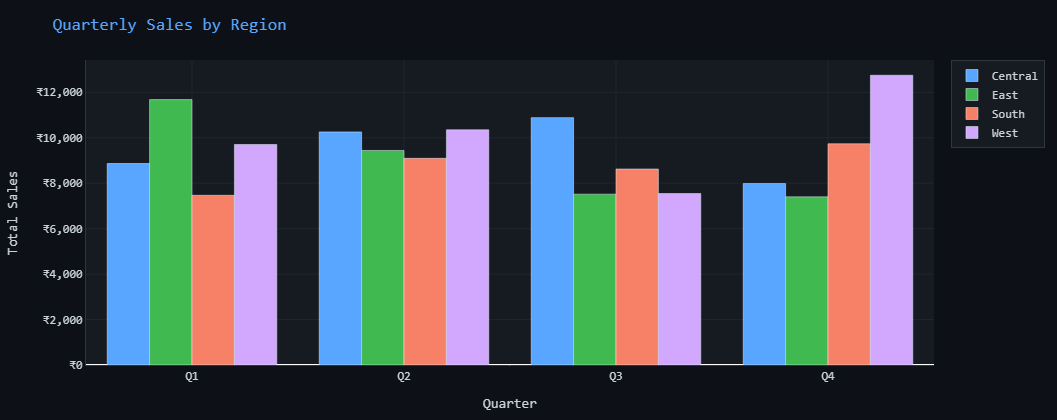

In [6]:
q_region = df.groupby(['Quarter','Region'])['Sales'].sum().reset_index()
q_region['Q_Label'] = 'Q' + q_region['Quarter'].astype(str)

fig = go.Figure()
for region, color in zip(df['Region'].unique(), COLORS):
    sub = q_region[q_region['Region'] == region]
    fig.add_trace(go.Bar(
        x=sub['Q_Label'], y=sub['Sales'],
        name=region, marker_color=color,
        hovertemplate=f'<b>{region}</b><br>Quarter: %{{x}}<br>Sales: ₹%{{y:,.0f}}<extra></extra>'
    ))

fig.update_layout(
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font=dict(color='#c9d1d9', family='monospace'),
    legend=dict(bgcolor='#161b22', bordercolor='#30363d', borderwidth=1),
    hoverlabel=dict(bgcolor='#1c2128', bordercolor='#58a6ff', font_color='#c9d1d9'),
    margin=dict(l=60, r=30, t=60, b=50),
    title=dict(text=' Quarterly Sales by Region', font=dict(size=17, color='#58a6ff')),
    barmode='group',
    xaxis=dict(gridcolor='#21262d', linecolor='#30363d', title='Quarter'),
    yaxis=dict(gridcolor='#21262d', linecolor='#30363d', tickprefix='₹', tickformat=',.0f', title='Total Sales'),
    height=420
)
fig.show()

---
##  Chart 6 — 6-Month Sales Forecast (Interactive)
Hover to see exact forecast values · Shaded area = confidence band

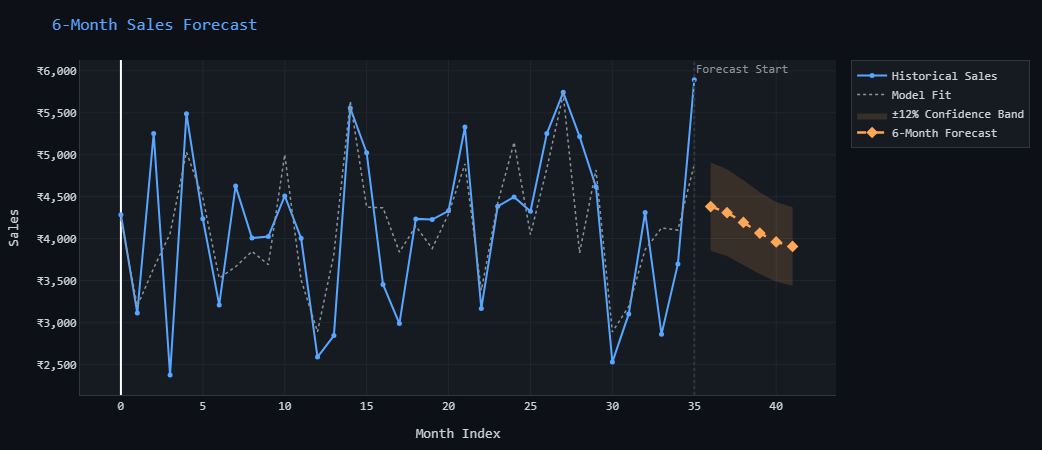


Model R² (full data): 0.5101

Forecast:
  Jan 2024  →  ₹4,381.79
  Feb 2024  →  ₹4,308.63
  Mar 2024  →  ₹4,192.72
  Apr 2024  →  ₹4,065.15
  May 2024  →  ₹3,960.13
  Jun 2024  →  ₹3,905.83


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

monthly_agg = df.groupby(['Year','Month']).agg(
    Total_Sales=('Sales','sum'),
    Order_Count=('Order_ID','count'),
    Avg_Discount=('Discount','mean')
).reset_index()
monthly_agg['Month_Index'] = range(len(monthly_agg))
monthly_agg['Month_Sin']   = np.sin(2*np.pi*monthly_agg['Month']/12)
monthly_agg['Month_Cos']   = np.cos(2*np.pi*monthly_agg['Month']/12)

features = ['Month_Index','Month_Sin','Month_Cos','Avg_Discount','Order_Count']
X = monthly_agg[features].values
y = monthly_agg['Total_Sales'].values
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

# Future months
last_idx = monthly_agg['Month_Index'].max()
last_month = int(monthly_agg['Month'].iloc[-1])
last_year  = int(monthly_agg['Year'].iloc[-1])
future = []
for i in range(1,7):
    mi = last_idx+i; m = ((last_month-1+i)%12)+1
    yr = last_year+(last_month+i-1)//12
    future.append({'Month_Index':mi,'Month_Sin':np.sin(2*np.pi*m/12),
                   'Month_Cos':np.cos(2*np.pi*m/12),
                   'Avg_Discount':monthly_agg['Avg_Discount'].mean(),
                   'Order_Count':monthly_agg['Order_Count'].mean(),
                   'Label':pd.Timestamp(year=yr,month=m,day=1).strftime('%b %Y'),
                   'Month_Index_val':mi})
future_df = pd.DataFrame(future)
future_df['Forecast'] = model.predict(future_df[features])
ci = future_df['Forecast'] * 0.12

fig = go.Figure()

# Historical actual
fig.add_trace(go.Scatter(
    x=monthly_agg['Month_Index'], y=y,
    mode='lines+markers', name='Historical Sales',
    line=dict(color='#58a6ff', width=2),
    marker=dict(size=5),
    hovertemplate='Month %{x}<br>Sales: ₹%{y:,.0f}<extra></extra>'
))

# Fitted line
fig.add_trace(go.Scatter(
    x=monthly_agg['Month_Index'], y=y_pred,
    mode='lines', name='Model Fit',
    line=dict(color='#8b949e', width=1.5, dash='dot'),
    hovertemplate='Month %{x}<br>Fitted: ₹%{y:,.0f}<extra></extra>'
))

# Confidence band
fig.add_trace(go.Scatter(
    x=pd.concat([future_df['Month_Index'], future_df['Month_Index'][::-1]]),
    y=pd.concat([future_df['Forecast']+ci, (future_df['Forecast']-ci)[::-1]]),
    fill='toself', fillcolor='rgba(255,166,87,0.15)',
    line=dict(color='rgba(0,0,0,0)'), name='±12% Confidence Band',
    hoverinfo='skip'
))

# Forecast line
fig.add_trace(go.Scatter(
    x=future_df['Month_Index'], y=future_df['Forecast'],
    mode='lines+markers', name='6-Month Forecast',
    line=dict(color='#ffa657', width=2.5, dash='dash'),
    marker=dict(size=9, symbol='diamond'),
    customdata=future_df['Label'],
    hovertemplate='<b>%{customdata}</b><br>Forecast: ₹%{y:,.0f}<extra></extra>'
))

fig.add_vline(x=last_idx, line_dash='dot', line_color='#30363d',
              annotation_text='Forecast Start', annotation_font_color='#8b949e')

fig.update_layout(
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font=dict(color='#c9d1d9', family='monospace'),
    legend=dict(bgcolor='#161b22', bordercolor='#30363d', borderwidth=1),
    hoverlabel=dict(bgcolor='#1c2128', bordercolor='#58a6ff', font_color='#c9d1d9'),
    margin=dict(l=60, r=30, t=60, b=50),
    title=dict(text=' 6-Month Sales Forecast', font=dict(size=17, color='#58a6ff')),
    xaxis=dict(gridcolor='#21262d', linecolor='#30363d', title='Month Index'),
    yaxis=dict(gridcolor='#21262d', linecolor='#30363d', tickprefix='₹', tickformat=',.0f', title='Sales'),
    height=450
)
fig.show()
print(f"\nModel R² (full data): {r2_score(y, y_pred):.4f}")
print("\nForecast:")
for _, row in future_df.iterrows():
    print(f"  {row['Label']}  →  ₹{row['Forecast']:,.2f}")

---
##  Chart 7 — Top Sub-Categories (Animated Bar)
Interactive horizontal bar — hover for exact values

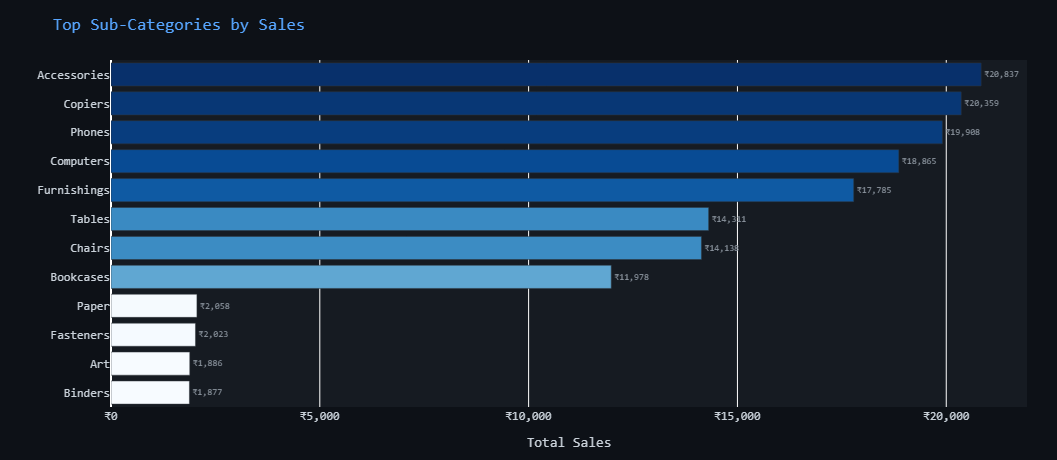

In [8]:
sub_stats = df.groupby('Sub_Category').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order_ID','count')
).reset_index().sort_values('Sales', ascending=True).tail(12)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=sub_stats['Sales'], y=sub_stats['Sub_Category'],
    orientation='h',
    marker=dict(
        color=sub_stats['Sales'],
        colorscale='Blues',
        showscale=False,
        line=dict(color='#30363d', width=0.5)
    ),
    customdata=np.stack([sub_stats['Profit'], sub_stats['Orders']], axis=-1),
    hovertemplate='<b>%{y}</b><br>Sales: ₹%{x:,.0f}<br>Profit: ₹%{customdata[0]:,.0f}<br>Orders: %{customdata[1]}<extra></extra>',
    text=[f'₹{v:,.0f}' for v in sub_stats['Sales']],
    textposition='outside', textfont=dict(color='#8b949e', size=9)
))

fig.update_layout(
    paper_bgcolor='#0d1117', plot_bgcolor='#161b22',
    font=dict(color='#c9d1d9', family='monospace'),
    legend=dict(bgcolor='#161b22', bordercolor='#30363d', borderwidth=1),
    hoverlabel=dict(bgcolor='#1c2128', bordercolor='#58a6ff', font_color='#c9d1d9'),
    margin=dict(l=60, r=30, t=60, b=50),
    title=dict(text=' Top Sub-Categories by Sales', font=dict(size=17, color='#58a6ff')),
    xaxis=dict(tickprefix='₹', tickformat=',.0f', title='Total Sales'),
    yaxis=dict(title=''),
    height=460
)
fig.show()